# Análisis Exploratorio de Datos de Ventas en E-commerce

# Autor: Eduardo Ferré Valderrama


## Introducción

Este notebook realiza un análisis exploratorio de datos (EDA) sobre un conjunto de datos de ventas en un e-commerce. El objetivo es explorar las características de los datos, identificar patrones y tendencias, y preparar los datos para un análisis más profundo.

El dataset contiene información sobre transacciones de ventas, incluyendo detalles del cliente, productos comprados, precios y fechas de compra. El análisis se centra en la identificación de tendencias de ventas, segmentación de clientes y análisis de productos.

Se utilizan bibliotecas como pandas, numpy, matplotlib y seaborn para la manipulación y visualización de datos. El análisis incluye la limpieza de datos, la exploración de variables, la identificación de valores atípicos y la creación de visualizaciones para comprender mejor los patrones en los datos.


## Importación de librerías y carga de datos


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

df = pd.read_csv("../data/ecommerce-dataset.csv")

## Vista preliminar e inspección general


In [2]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_Date           51290 non-null  object 
 1   Time                 51290 non-null  object 
 2   Aging                51289 non-null  float64
 3   Customer_Id          51290 non-null  int64  
 4   Gender               51290 non-null  object 
 5   Device_Type          51290 non-null  object 
 6   Customer_Login_type  51290 non-null  object 
 7   Product_Category     51290 non-null  object 
 8   Product              51290 non-null  object 
 9   Sales                51289 non-null  float64
 10  Quantity             51288 non-null  float64
 11  Discount             51289 non-null  float64
 12  Profit               51290 non-null  float64
 13  Shipping_Cost        51289 non-null  float64
 14  Order_Priority       51288 non-null  object 
 15  Payment_method       51290 non-null 

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,2018-01-02,10:56:33,8.0,37077,Female,Web,Member,Auto & Accessories,Car Media Players,140.0,1.0,0.3,46.0,4.6,Medium,credit_card
1,2018-07-24,20:41:37,2.0,59173,Female,Web,Member,Auto & Accessories,Car Speakers,211.0,1.0,0.3,112.0,11.2,Medium,credit_card
2,2018-11-08,08:38:49,8.0,41066,Female,Web,Member,Auto & Accessories,Car Body Covers,117.0,5.0,0.1,31.2,3.1,Critical,credit_card
3,2018-04-18,19:28:06,7.0,50741,Female,Web,Member,Auto & Accessories,Car & Bike Care,118.0,1.0,0.3,26.2,2.6,High,credit_card
4,2018-08-13,21:18:39,9.0,53639,Female,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.3,160.0,16.0,Critical,credit_card


Se inspecciona la estructura del dataset para entender cuántas columnas y registros tiene, así como los tipos de datos.

El dataset contiene **51.290 registros** y **16 columnas** que describen distintos aspectos de transacciones en una tienda online: datos del cliente (`Customer_Id`, `Gender`, `Device_Type`), del producto (`Product`, `Product_Category`, `Sales`, `Quantity`, etc.), y de la orden (`Order_Date`, `Time`, `Order_Priority`, `Payment_method`, etc.).

Observamos que las columnas `Order_Date` y `Time` están en formato `object`, por lo que se deberán convertir a formatos de fecha y hora (`datetime`) para facilitar análisis temporales.


## Análisis de valores nulos


In [3]:
df.isnull().sum()

Order_Date             0
Time                   0
Aging                  1
Customer_Id            0
Gender                 0
Device_Type            0
Customer_Login_type    0
Product_Category       0
Product                0
Sales                  1
Quantity               2
Discount               1
Profit                 0
Shipping_Cost          1
Order_Priority         2
Payment_method         0
dtype: int64

Se detectaron valores nulos en 6 columnas, pero representaban menos del 0.01% del dataset. Por ello, se optará por eliminar las filas correspondientes para mantener la integridad del análisis sin afectar la muestra.


In [4]:
df.isnull()

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
51286,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
51287,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
51288,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## Limpieza de datos


In [5]:
# Eliminamos duplicados 
df.drop_duplicates(inplace=True)

# Eliminamos filas con valores nulos
df.dropna(inplace=True)

# Convertimos fechas
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.time


Se eliminan posibles filas duplicadas y aquellas que contienen valores nulos. También se realiza la conversión de los campos `Order_Date` y `Time` al formato adecuado, lo que permitirá agrupar por día, mes, año, o analizar el comportamiento horario.


## Análisis exploratorio de datos (EDA)


### Ventas Generales


In [6]:
# Total de ventas ($)
total_sales = df['Sales'].sum()
total_units = df['Quantity'].sum()

print(f"Total de ventas: ${total_sales:,.2f}")
print(f"Total de unidades vendidas: {int(total_units)}")


Total de ventas: $7,812,164.00
Total de unidades vendidas: 128357


El total de ventas registradas en el período es de aproximadamente **$7,812,164**, con un total de **128357 unidades vendidas**.

Ahora analizaremos cómo se distribuyen esas ventas a lo largo del tiempo.


#### Ventas por mes


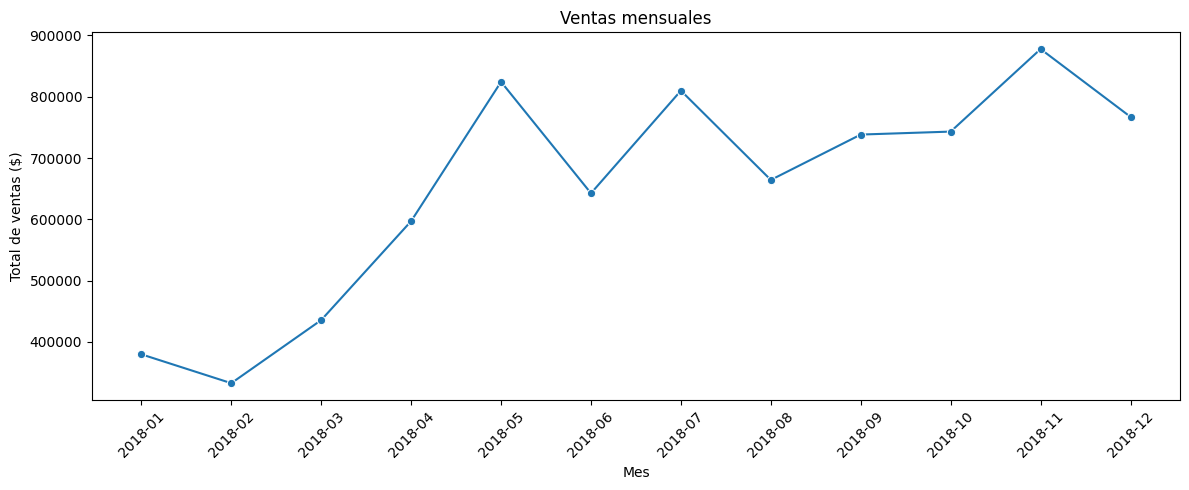

In [17]:
df['Order_Month'] = df['Order_Date'].dt.to_period('M')
monthly_sales = df.groupby('Order_Month')['Sales'].sum().reset_index()
monthly_sales['Order_Month'] = monthly_sales['Order_Month'].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='Order_Month', y='Sales', marker='o')
plt.xticks(rotation=45)
plt.title('Ventas mensuales')
plt.ylabel('Total de ventas ($)')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()


#### Ventas por día de la semana y hora


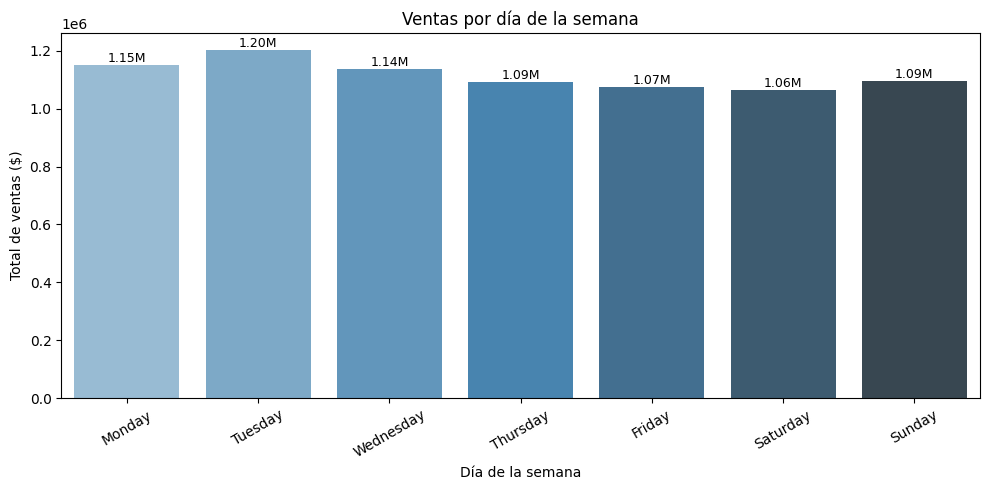

In [18]:
df['Weekday'] = df['Order_Date'].dt.day_name()
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

weekdays_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Ventas por día de la semana

plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=df,                     
    x='Weekday',                
    y='Sales',                  
    estimator=sum,               
    order=weekdays_order,        
    palette='Blues_d',   # Habría que ver si es conveniente usar alguna paleta o dejar todo en azul        
    ci='sd'                     
)

plt.title('Ventas por día de la semana')
plt.ylabel('Total de ventas ($)')
plt.xlabel('Día de la semana')
plt.xticks(rotation=30)

for p in ax.patches:  # Itera sobre cada barra
    height = p.get_height()  # Obtiene la altura (valor de ventas)
    ax.annotate(
        f'{height/1e6:.2f}M',                       # Formatea el número en millones (ej. 1.20M)
        (p.get_x() + p.get_width() / 2, height),    # Posición: centro de la barra, arriba del valor
        ha='center', va='bottom', fontsize=9, color='black'  # Ajustes estéticos
    )


plt.tight_layout()
plt.show()

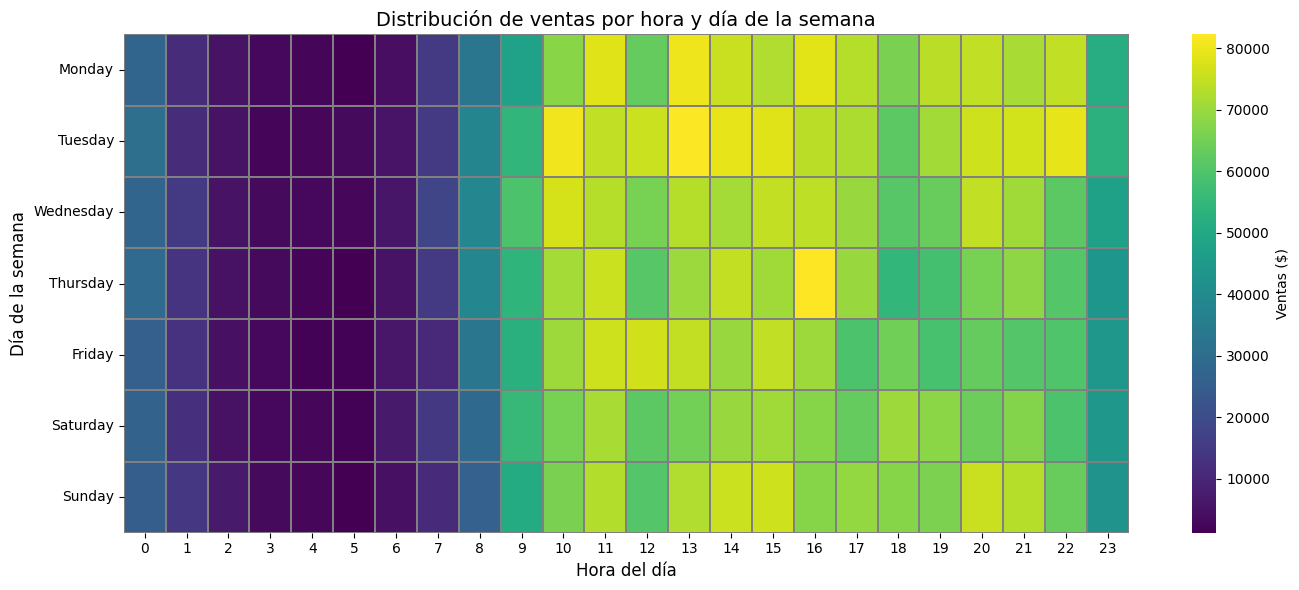

In [20]:

# Heatmap de hora vs día
pivot = df.pivot_table(
    values='Sales',  
    index='Weekday',  
    columns='Hour',  
    aggfunc='sum'     
)

pivot = pivot.reindex(weekdays_order)

plt.figure(figsize=(14,6))
sns.heatmap(
    pivot,                    
    cmap='viridis',          
    linewidths=0.3,           
    linecolor='gray',         
    cbar_kws={'label': 'Ventas ($)'}  
)

plt.title('Distribución de ventas por hora y día de la semana', fontsize=14)
plt.xlabel('Hora del día', fontsize=12)
plt.ylabel('Día de la semana', fontsize=12)
plt.tight_layout() # Ajustar márgenes automáticamente
plt.show()         


### Productos


#### Top 10 productos más vendidos


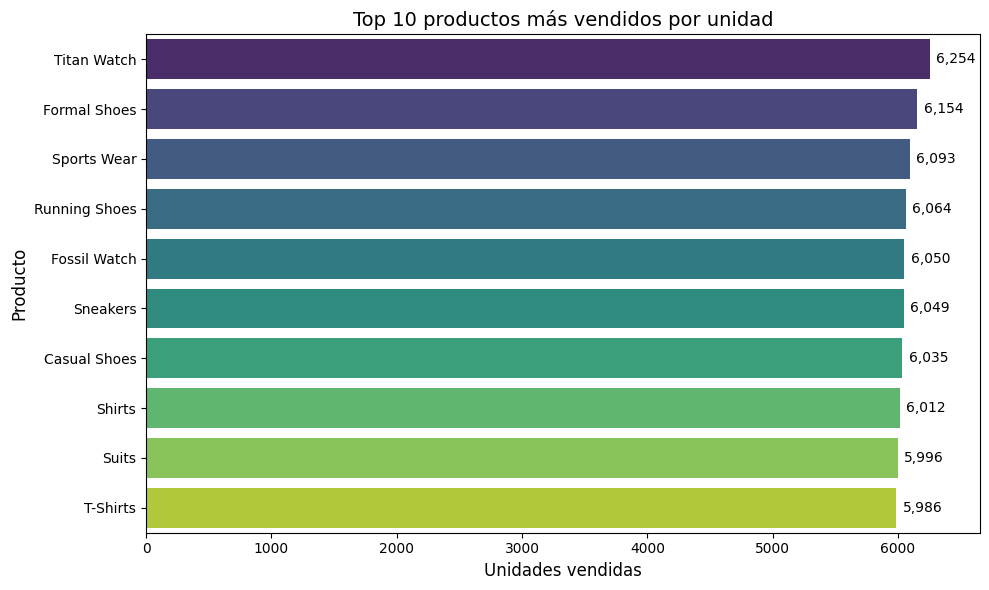

In [ ]:
top_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(10)

# Es correcto esto?
top_products.index = top_products.index.str.replace('Titak watch', 'Titan Watch')
top_products.index = top_products.index.str.replace('Casula Shoes', 'Casual Shoes')
top_products.index = top_products.index.str.replace('T - Shirts', 'T-Shirts')

plt.figure(figsize=(10, 6)) 

# Gráfico de barras horizontales
ax = sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette='viridis'
)

plt.title('Top 10 productos más vendidos por unidad', fontsize=14)
plt.xlabel('Unidades vendidas', fontsize=12)
plt.ylabel('Producto', fontsize=12)

# Agregar anotaciones al final de cada barra
for i, (value, label) in enumerate(zip(top_products.values, top_products.index)):
    ax.text(value + 50, i, f'{value:,.0f}', va='center', fontsize=10, color='black') # 50 es un pequeño espacio

plt.xlim(0, top_products.max() + 400)

plt.tight_layout()
plt.show()

Los productos más vendidos se identifican según la suma total de unidades. Esto permite detectar artículos populares que generan alto volumen de ventas, independientemente de su precio.


#### Productos más rentables


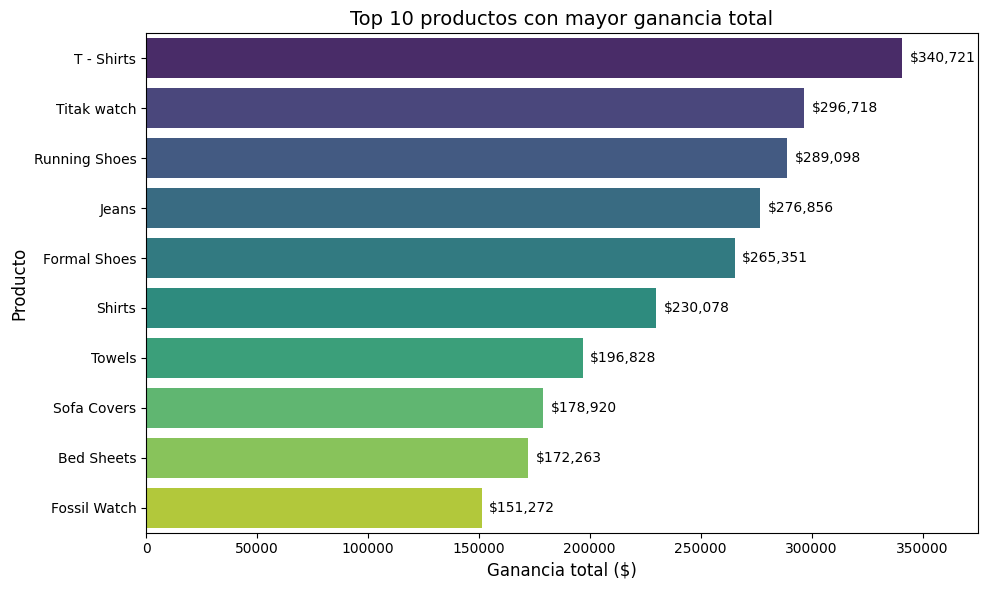

In [28]:
# Rentabilidad = suma total del Profit por producto
profitable_products = df.groupby('Product')['Profit'].sum().sort_values(ascending=False).head(10)

top_products.index = top_products.index.str.replace('Titak watch', 'Titan Watch')
top_products.index = top_products.index.str.replace('Casula Shoes', 'Casual Shoes')
top_products.index = top_products.index.str.replace('T - Shirts', 'T-Shirts')

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=profitable_products.values,
    y=profitable_products.index,
    palette='viridis'
)

plt.title('Top 10 productos con mayor ganancia total', fontsize=14)
plt.xlabel('Ganancia total ($)', fontsize=12)
plt.ylabel('Producto', fontsize=12)

# Agregar anotaciones con los valores de ganancia
for i, (value, label) in enumerate(zip(profitable_products.values, profitable_products.index)):
    ax.text(value + abs(profitable_products.max()) * 0.01, i, f'${value:,.0f}', 
            va='center', fontsize=10, color='white' if value < 0 else 'black')

plt.xlim(0, profitable_products.max() * 1.1)
plt.tight_layout()
plt.show()


Aquí se identifican los productos que generan mayor ganancia total. Es útil para detectar cuáles aportan más al margen de beneficio, más allá del volumen vendido.


#### Productos con y sin descuentos


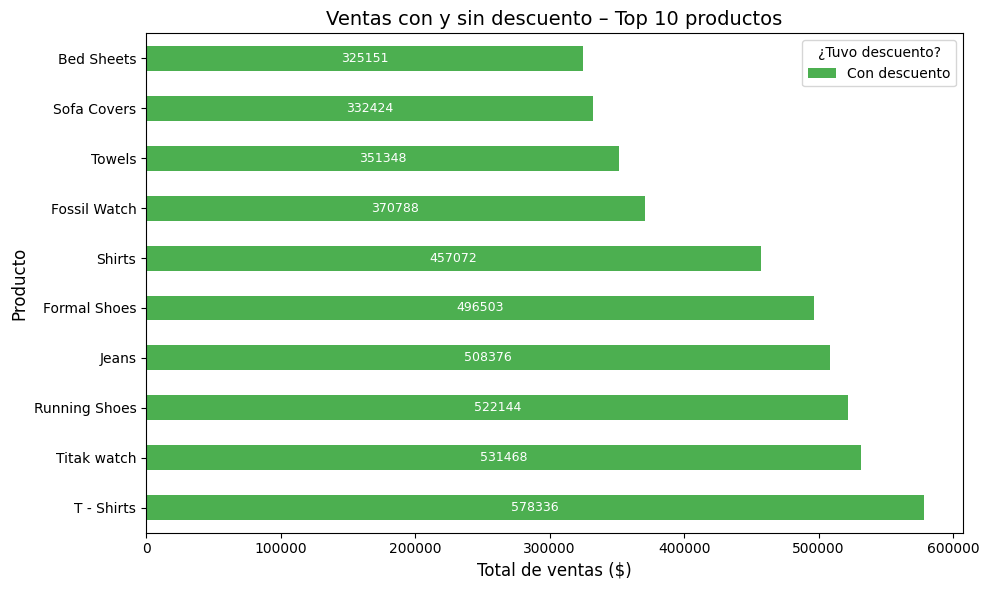

In [34]:
# Crear columna booleana
df['Has_Discount'] = df['Discount'] > 0

# Agrupar ventas por producto y si tuvo descuento
discount_summary = df.groupby(['Product', 'Has_Discount'])['Sales'].sum().unstack().fillna(0)

# Renombrar columnas si ambas existen
if discount_summary.columns.tolist() == [False, True]:
    discount_summary.columns = ['Sin descuento', 'Con descuento']
elif discount_summary.columns.tolist() == [True, False]:
    discount_summary.columns = ['Con descuento', 'Sin descuento']
elif discount_summary.columns.tolist() == [True]:
    discount_summary.columns = ['Con descuento']
elif discount_summary.columns.tolist() == [False]:
    discount_summary.columns = ['Sin descuento']
else:
    raise ValueError("Las columnas no son las esperadas.")

# Agregar columna total para ordenar
discount_summary['Total'] = discount_summary.sum(axis=1)

# Ordenar por ventas totales
discount_summary = discount_summary.sort_values('Total', ascending=False).drop(columns='Total')

# Tomar top 10 productos
sample = discount_summary.head(10)

# Gráfico apilado
ax = sample.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 6),
    color=['#4caf50', '#f44336'][:sample.shape[1]]  # ajustar colores a las columnas disponibles
)

# Título y etiquetas
plt.title('Ventas con y sin descuento – Top 10 productos', fontsize=14)
plt.xlabel('Total de ventas ($)', fontsize=12)
plt.ylabel('Producto', fontsize=12)
plt.legend(title='¿Tuvo descuento?')

# Etiquetas sobre cada barra
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f', label_type='center', fontsize=9, color='white')

plt.tight_layout()
plt.show()
